# SINDy on the Sardine–Anchovy–SST Dataset
## Discrete-time, 4-variable model with automatic global λ selection

**State vector**: $\mathbf{x}_t = [\text{anchovy},\ \text{sardine},\ \text{SIO-SST},\ \text{NP-SST}]$

### λ selection logic (two-phase approach)

**Phase 1 — unconstrained fit (λ = 0):** run plain least-squares on the full library. This gives all 60 coefficients (15 features × 4 equations) their best-fit values with no sparsity constraint. These represent the raw importance of every candidate term.

**Phase 2 — rank and threshold globally:** sort all 60 |coefficients| together. Set λ = the (100 − `top_pct`)-th percentile. This keeps only the `top_pct`% most influential terms *across all equations*, regardless of which equation they belong to. A term only survives if it is genuinely large relative to every other term in the whole system.

**Phase 3 — STLS with found λ:** re-run sequential thresholded least-squares using this λ. The iterative re-fitting ensures the surviving coefficients are accurate after the weak terms have been removed.

The candidate library can optionally include **sin and cos** of each state variable in addition to the polynomial terms, giving SINDy the chance to discover oscillatory or periodic structure in the dynamics. A flag `INCLUDE_TRIG` controls this.

In [23]:
import gzip, struct
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations_with_replacement
from scipy.linalg import lstsq

np.random.seed(42)
plt.rcParams.update({'font.size': 11, 'figure.dpi': 100})

---
## Step 1 — Load data

In [24]:
def load_sardine_data(path='sardine_anchovy_sst.RData'):
    with gzip.open(path) as gz:
        raw = gz.read()
    years = np.array([struct.unpack('>i', raw[62+8+i*4:62+8+i*4+4])[0] for i in range(78)])
    blocks, pos = [], 0
    while True:
        idx = raw.find(b'\x00\x00\x00\x0e\x00\x00\x00\x4e', pos)
        if idx < 0: break
        blocks.append(np.array([struct.unpack('>d', raw[idx+8+i*8:idx+8+i*8+8])[0] for i in range(78)]))
        pos = idx + 1
    anchovy, sardine, sio_sst, np_sst = blocks
    return years, anchovy, sardine, sio_sst, np_sst

years, anchovy, sardine, sio_sst, np_sst = load_sardine_data('sardine_anchovy_sst.RData')
print(f'Loaded: {len(years)} annual observations, {years[0]}–{years[-1]}')
print('All variables are z-score standardised (mean=0, std=1)')
print()
for name, col in [('anchovy', anchovy), ('sardine', sardine), ('sio_sst', sio_sst), ('np_sst', np_sst)]:
    print(f'  {name:8s}  mean={col.mean():+.4f}  std={col.std():.4f}  min={col.min():.3f}  max={col.max():.3f}')

Loaded: 78 annual observations, 1929–2006
All variables are z-score standardised (mean=0, std=1)

  anchovy   mean=-0.0000  std=1.0000  min=-4.532  max=3.460
  sardine   mean=-0.0000  std=1.0000  min=-2.867  max=2.990
  sio_sst   mean=-0.0000  std=1.0000  min=-1.766  max=2.398
  np_sst    mean=+0.0000  std=1.0000  min=-2.218  max=1.963


---
## Step 2 — Visualise time series

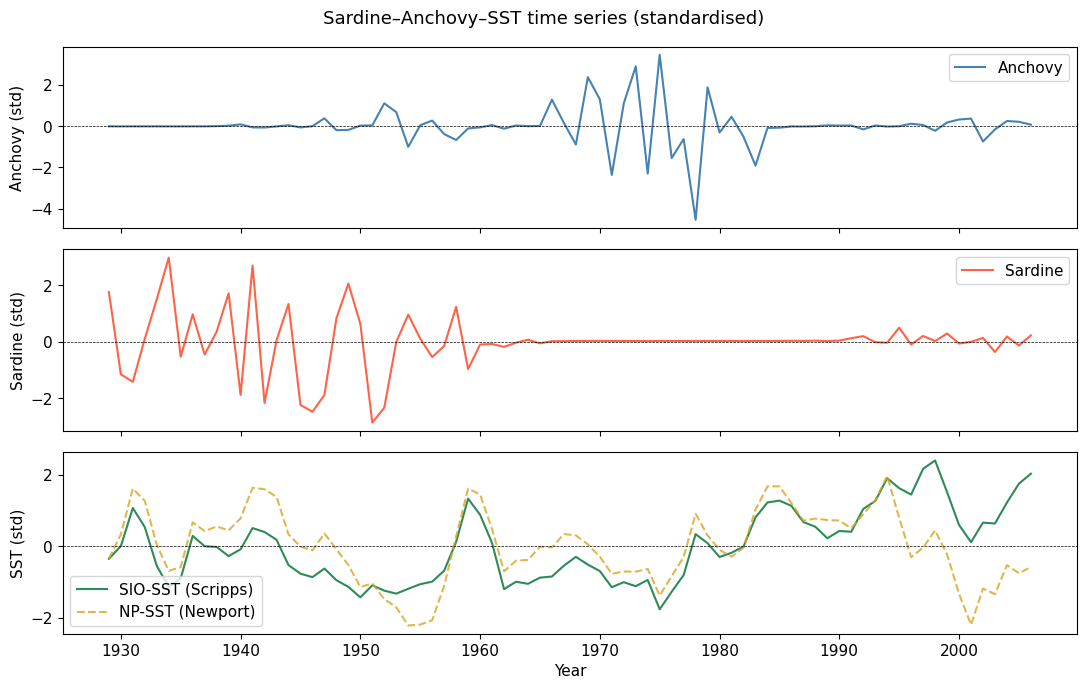

In [25]:
fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)
axes[0].plot(years, anchovy, 'steelblue', lw=1.5, label='Anchovy')
axes[0].axhline(0, color='k', lw=0.5, ls='--'); axes[0].set_ylabel('Anchovy (std)'); axes[0].legend()
axes[1].plot(years, sardine, 'tomato', lw=1.5, label='Sardine')
axes[1].axhline(0, color='k', lw=0.5, ls='--'); axes[1].set_ylabel('Sardine (std)'); axes[1].legend()
axes[2].plot(years, sio_sst, 'seagreen', lw=1.5, label='SIO-SST (Scripps)')
axes[2].plot(years, np_sst, 'goldenrod', lw=1.5, ls='--', label='NP-SST (Newport)', alpha=0.8)
axes[2].axhline(0, color='k', lw=0.5, ls='--'); axes[2].set_ylabel('SST (std)'); axes[2].set_xlabel('Year'); axes[2].legend()
fig.suptitle('Sardine–Anchovy–SST time series (standardised)', fontsize=13)
plt.tight_layout(); plt.show()

---
## Step 3 — Core functions

### `poolData` — builds the candidate library Θ
### `sparsifyDynamics` — two-phase SINDy with automatic global λ

In [26]:
def poolData(X, poly_order=2, var_names=None, include_trig=False):
    """Build candidate library Theta(X): all polynomial terms up to poly_order,
    plus optionally sin and cos of each state variable.
    Returns (Theta matrix, list of feature names)."""
    m, n = X.shape
    if var_names is None:
        var_names = ['x' + str(i) for i in range(n)]
    cols, names = [np.ones(m)], ['1']
    for order in range(1, poly_order + 1):
        for combo in combinations_with_replacement(range(n), order):
            cols.append(np.prod(X[:, combo], axis=1))
            names.append(''.join(var_names[c] for c in combo))
    if include_trig:
        for i in range(n):
            cols.append(np.sin(X[:, i]))
            names.append(f'sin({var_names[i]})')
        for i in range(n):
            cols.append(np.cos(X[:, i]))
            names.append(f'cos({var_names[i]})')
    return np.column_stack(cols), names


def sparsifyDynamics(Theta, Y, top_pct=20, n_iter=10):
    """
    Two-phase SINDy with automatic global lambda selection.

    Phase 1: unconstrained least-squares (lambda=0) to get the raw
             importance of every candidate term across all equations.

    Phase 2: rank ALL coefficients globally (across all equations).
             Set lambda = (100-top_pct)-th percentile of |Xi0|.
             This keeps only the top_pct% most influential terms system-wide.

    Phase 3: re-run STLS with this lambda (n_iter iterations of
             threshold-and-refit) to get accurate final coefficients.

    Parameters
    ----------
    Theta   : (m, p) library matrix
    Y       : (m, n) target matrix — next-year values
    top_pct : float — percentage of terms to keep globally.
              e.g. top_pct=20 keeps the 20% largest |coefficients|
              across ALL equations combined.
    n_iter  : number of STLS refinement iterations

    Returns
    -------
    Xi      : (p, n) sparse coefficient matrix
    lamb    : float, the threshold used
    Xi0     : (p, n) initial unconstrained solution (for inspection)
    """
    n_states = Y.shape[1]

    # ── Phase 1: unconstrained fit ────────────────────────────────────────
    Xi0, _, _, _ = lstsq(Theta, Y)

    # ── Phase 2: find global lambda ───────────────────────────────────────
    all_abs = np.abs(Xi0).flatten()           # all p×n coefficients together
    lamb    = float(np.percentile(all_abs, 100 - top_pct))

    # ── Phase 3: STLS with found lambda ───────────────────────────────────
    Xi = Xi0.copy()
    for _ in range(n_iter):
        small = np.abs(Xi) < lamb
        Xi[small] = 0.0
        for ind in range(n_states):
            big = ~small[:, ind]
            if big.sum() == 0:
                continue
            Xi[big, ind], _, _, _ = lstsq(Theta[:, big], Y[:, ind])

    return Xi, lamb, Xi0


def r_squared(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    return 1 - ss_res / ss_tot


# ── Assemble data matrices ────────────────────────────────────────────────────
state_names  = ['a', 's', 'TS', 'TN']                             # a=anchovy, s=sardine, TS=SIO-SST, TN=NP-SST
INCLUDE_TRIG = True    # ← set False to use polynomial-only library
X     = np.column_stack([anchovy, sardine, sio_sst, np_sst])     # (78, 4)
X_t   = X[:-1]    # x(t)   — 77 rows
X_tp1 = X[1:]     # x(t+1) — 77 rows (targets)

Theta, feat = poolData(X_t, poly_order=2, var_names=state_names, include_trig=INCLUDE_TRIG)
n_total_coeffs = Theta.shape[1] * X_tp1.shape[1]
print(f'Library: {Theta.shape[1]} features × {Theta.shape[0]} time steps')
print(f'Total coefficients to rank: {n_total_coeffs}  ({Theta.shape[1]} features × 4 equations)')
print('Features:', feat)

Library: 23 features × 77 time steps
Total coefficients to rank: 92  (23 features × 4 equations)
Features: ['1', 'a', 's', 'TS', 'TN', 'aa', 'as', 'aTS', 'aTN', 'ss', 'sTS', 'sTN', 'TSTS', 'TSTN', 'TNTN', 'sin(a)', 'sin(s)', 'sin(TS)', 'sin(TN)', 'cos(a)', 'cos(s)', 'cos(TS)', 'cos(TN)']


---
## Step 4 — Inspect the unconstrained solution (Phase 1)

Before any thresholding, show all coefficients ranked by magnitude.
This is the raw signal that λ selection is based on.

> **Note on trig terms:** sin and cos of standardised data are bounded in [−1, 1], so their coefficients can be much larger than polynomial coefficients for the same amount of explained variance. This is expected — they are on a different scale, not necessarily more important. The global ranking handles this correctly: a large sin(TS) coefficient competes directly against a large TS coefficient, and the top_pct% cut keeps whichever are genuinely biggest.

In [27]:
TOP_PCT = 40   # ← percentage of terms to keep globally
#               recommended: ~20-30 for poly-only, ~40-50 when trig is included

var_labels = ['Anchovy', 'Sardine', 'SIO-SST', 'NP-SST']
short = {'a': 'anchovy', 's': 'sardine', 'TS': 'SIO-SST', 'TN': 'NP-SST'}

# Run phase 1 only (to inspect Xi0)
Xi0, _, _, _ = lstsq(Theta, X_tp1)

# Rank all 60 coefficients globally
entries = []
for i, lab in enumerate(var_labels):
    for j, fname in enumerate(feat):
        entries.append((abs(Xi0[j, i]), Xi0[j, i], fname, lab))
entries.sort(reverse=True)

all_abs = np.array([e[0] for e in entries])
lamb_preview = float(np.percentile(all_abs, 100 - TOP_PCT))
n_survive = int(np.sum(all_abs >= lamb_preview))

print(f'All {len(entries)} coefficients ranked by |value|  (top_pct={TOP_PCT}%)')
print(f'Global λ = {lamb_preview:.4f}  →  {n_survive} terms will survive')
print()
print(f'{"Rank":>4}  {"  |coeff|":>10}  {"value":>8}  {"feature":>8}  equation')
print('─' * 55)
for rank, (absv, v, fname, eq) in enumerate(entries, 1):
    marker = '  ✓ keep' if absv >= lamb_preview else ''
    print(f'{rank:4d}   {absv:8.4f}   {v:+8.4f}   {fname:>8}   {eq}{marker}')

All 92 coefficients ranked by |value|  (top_pct=40%)
Global λ = 0.4201  →  37 terms will survive

Rank     |coeff|     value   feature  equation
───────────────────────────────────────────────────────
   1     7.8992    +7.8992          1   Sardine  ✓ keep
   2     6.2234    -6.2234    cos(TN)   Sardine  ✓ keep
   3     4.0010    -4.0010    sin(TS)   Sardine  ✓ keep
   4     3.0759    -3.0759    cos(TS)   Sardine  ✓ keep
   5     2.7786    +2.7786         TS   Sardine  ✓ keep
   6     2.0827    +2.0827    cos(TN)   SIO-SST  ✓ keep
   7     2.0344    -2.0344       TNTN   Sardine  ✓ keep
   8     1.8861    +1.8861    cos(TN)   NP-SST  ✓ keep
   9     1.5131    -1.5131       TSTS   Sardine  ✓ keep
  10     1.1654    -1.1654         as   Sardine  ✓ keep
  11     1.1405    +1.1405    sin(TS)   Anchovy  ✓ keep
  12     1.0679    +1.0679         TS   SIO-SST  ✓ keep
  13     1.0225    +1.0225     sin(a)   Anchovy  ✓ keep
  14     1.0212    -1.0212     cos(s)   NP-SST  ✓ keep
  15     0.9402  

---
## Step 5 — Run full SINDy (Phases 2 + 3) and inspect results

In [28]:
Xi, lamb, Xi0 = sparsifyDynamics(Theta, X_tp1, top_pct=TOP_PCT)

print(f'Global λ = {lamb:.4f}  (keeps top {TOP_PCT}% of all {n_total_coeffs} coefficients)')
print(f'Active terms after STLS: {np.sum(np.abs(Xi) > 1e-10)}')
print()

# One-step-ahead predictions
X_pred = Theta @ Xi

# R² per variable
for i, lab in enumerate(var_labels):
    r2 = r_squared(X_tp1[:, i], X_pred[:, i])
    print(f'{lab:10s}  R² = {r2:.3f}')

# Print identified equations
print()
print('═' * 65)
print('Identified discrete-time model  x(t+1) = F(x(t))')
print('═' * 65)
eq_names = ['anchovy(t+1) ', 'sardine(t+1) ', 'SIO-SST(t+1) ', 'NP-SST(t+1)  ']
for i, eq_name in enumerate(eq_names):
    terms = []
    for j, name in enumerate(feat):
        c = Xi[j, i]
        if abs(c) > 1e-10:
            display = name
            for k, v in short.items():
                display = display.replace(k, v)
            terms.append(f'{c:+.3f}·{display}' if display != '1' else f'{c:+.3f}')
    rhs = '  '.join(terms) if terms else '0  (no terms survived — try raising top_pct)'
    print(f'  {eq_name} =  {rhs}')
print('═' * 65)

Global λ = 0.4201  (keeps top 40% of all 92 coefficients)
Active terms after STLS: 7

Anchovy     R² = 0.157
Sardine     R² = 0.134
SIO-SST     R² = 0.757
NP-SST      R² = 0.646

═════════════════════════════════════════════════════════════════
Identified discrete-time model  x(t+1) = F(x(t))
═════════════════════════════════════════════════════════════════
  anchovy(t+1)  =  -0.441·anchovy  +0.602·sardinein(anchovy)
  sardine(t+1)  =  -0.497  -0.495·anchovysardine  +0.653·cosardine(sardine)
  SIO-SST(t+1)  =  +0.893·SIO-SST
  NP-SST(t+1)   =  +0.805·NP-SST
═════════════════════════════════════════════════════════════════


---
## Step 6 — One-step-ahead predictions vs observations

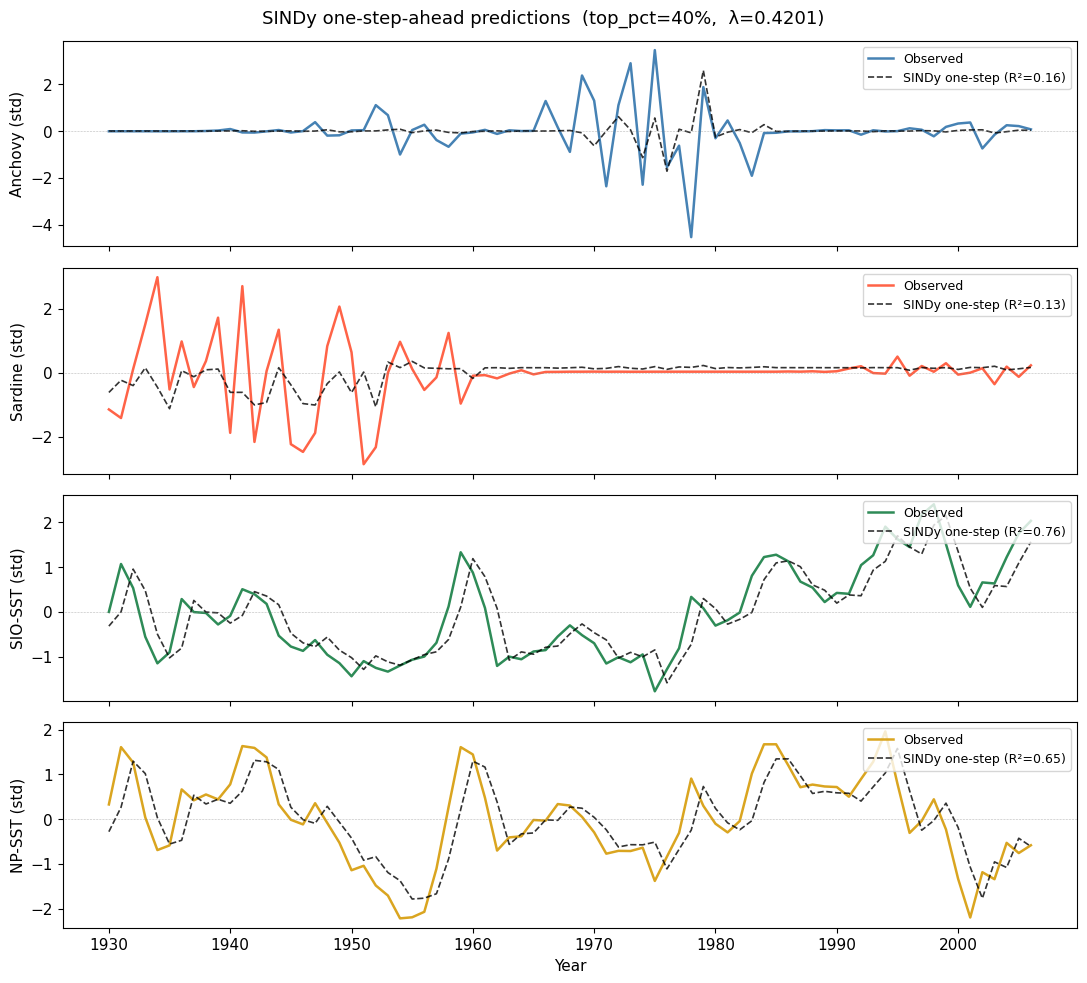

In [29]:
colors = ['steelblue', 'tomato', 'seagreen', 'goldenrod']
fig, axes = plt.subplots(4, 1, figsize=(11, 10), sharex=True)
for i, (lab, col) in enumerate(zip(var_labels, colors)):
    r2 = r_squared(X_tp1[:, i], X_pred[:, i])
    axes[i].plot(years[1:], X_tp1[:, i],  color=col, lw=1.8, label='Observed')
    axes[i].plot(years[1:], X_pred[:, i], color='k', lw=1.2, ls='--', alpha=0.8,
                 label=f'SINDy one-step (R²={r2:.2f})')
    axes[i].axhline(0, color='grey', lw=0.4, ls=':')
    axes[i].set_ylabel(f'{lab} (std)')
    axes[i].legend(loc='upper right', fontsize=9)
axes[-1].set_xlabel('Year')
fig.suptitle(f'SINDy one-step-ahead predictions  (top_pct={TOP_PCT}%,  λ={lamb:.4f})', fontsize=13)
plt.tight_layout(); plt.show()

---
## Step 7 — Effect of `top_pct` on sparsity and fit quality

Sweeps `top_pct` from 5% to 60% and shows:
- how many terms survive globally
- R² per variable
- the corresponding λ value

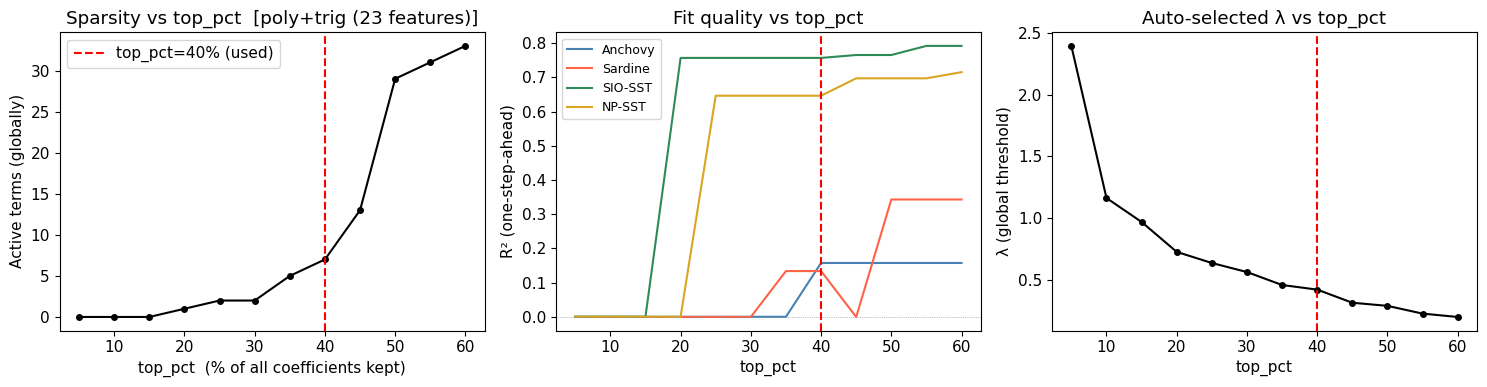

In [30]:
pct_range     = np.arange(5, 61, 5)
n_active_list = []
r2_lists      = [[] for _ in range(4)]
lamb_list     = []

for pct in pct_range:
    Xi_p, lamb_p, _ = sparsifyDynamics(Theta, X_tp1, top_pct=pct)
    pred_p = Theta @ Xi_p
    n_active_list.append(np.sum(np.abs(Xi_p) > 1e-10))
    lamb_list.append(lamb_p)
    for i in range(4):
        r2_lists[i].append(r_squared(X_tp1[:, i], pred_p[:, i]))

lib_label = f'poly+trig ({Theta.shape[1]} features)' if INCLUDE_TRIG else f'poly-only ({Theta.shape[1]} features)'
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(pct_range, n_active_list, 'k-o', ms=4)
axes[0].axvline(TOP_PCT, color='r', ls='--', label=f'top_pct={TOP_PCT}% (used)')
axes[0].set_xlabel('top_pct  (% of all coefficients kept)')
axes[0].set_ylabel('Active terms (globally)')
axes[0].set_title(f'Sparsity vs top_pct  [{lib_label}]'); axes[0].legend()

for i, (lab, col) in enumerate(zip(var_labels, colors)):
    axes[1].plot(pct_range, r2_lists[i], color=col, label=lab, lw=1.5)
axes[1].axvline(TOP_PCT, color='r', ls='--')
axes[1].axhline(0, color='grey', lw=0.5, ls=':')
axes[1].set_xlabel('top_pct'); axes[1].set_ylabel('R² (one-step-ahead)')
axes[1].set_title('Fit quality vs top_pct'); axes[1].legend(fontsize=9)

axes[2].plot(pct_range, lamb_list, 'k-o', ms=4)
axes[2].axvline(TOP_PCT, color='r', ls='--')
axes[2].set_xlabel('top_pct'); axes[2].set_ylabel('λ (global threshold)')
axes[2].set_title('Auto-selected λ vs top_pct')

plt.tight_layout(); plt.show()

---
## Step 8 — Multi-step simulation

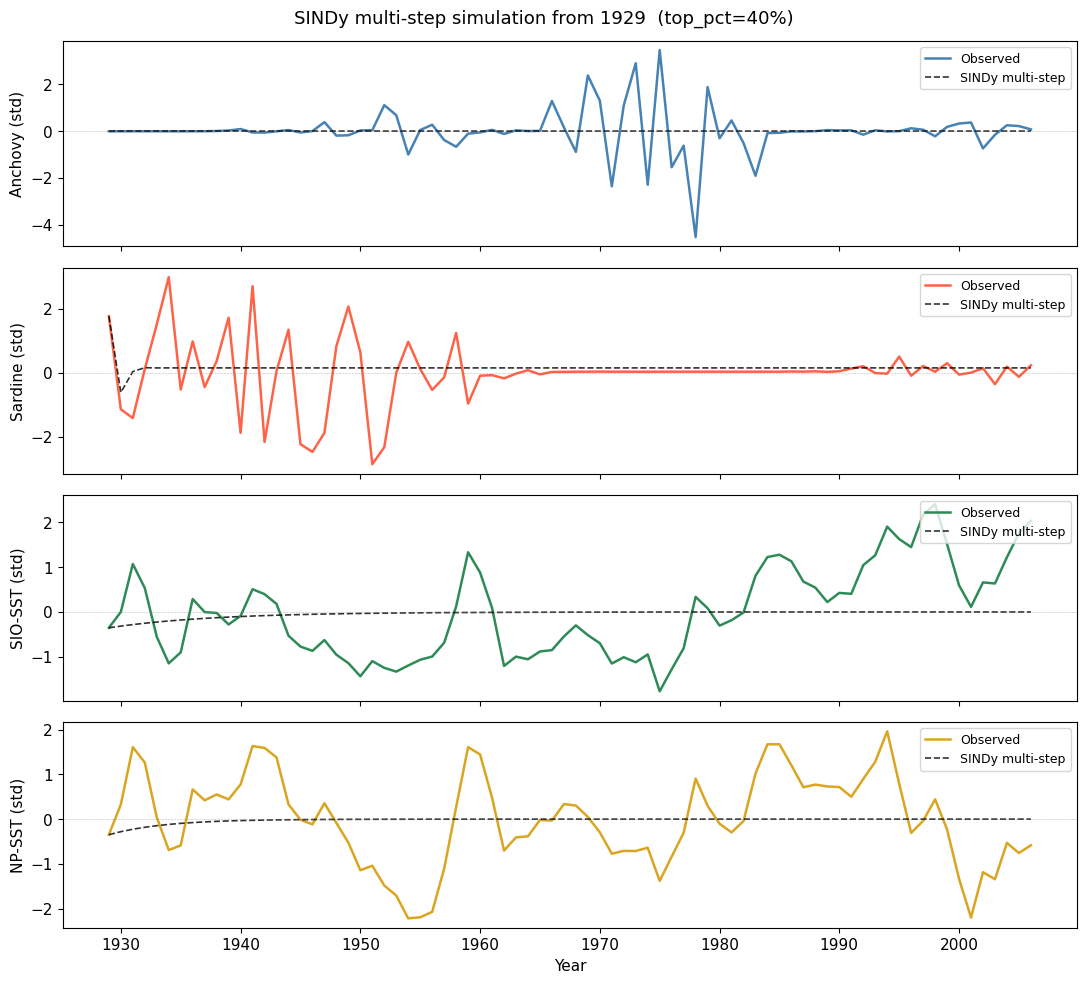

Simulation stable: True


In [31]:
def simulate_sindy(x0, Xi, poly_order, var_names, n_steps, include_trig=False):
    """Iterate the identified discrete-time map forward from x0."""
    traj = [x0.copy()]
    x = x0.copy()
    for _ in range(n_steps):
        th, _ = poolData(x.reshape(1, -1), poly_order=poly_order,
                         var_names=var_names, include_trig=include_trig)
        x = (th @ Xi).flatten()
        traj.append(x.copy())
    return np.array(traj)

traj = simulate_sindy(X[0], Xi, poly_order=2, var_names=state_names,
                      n_steps=77, include_trig=INCLUDE_TRIG)

fig, axes = plt.subplots(4, 1, figsize=(11, 10), sharex=True)
for i, (lab, col) in enumerate(zip(var_labels, colors)):
    axes[i].plot(years, X[:, i],    color=col, lw=1.8, label='Observed')
    axes[i].plot(years, traj[:, i], color='k', lw=1.2, ls='--', alpha=0.8, label='SINDy multi-step')
    axes[i].axhline(0, color='grey', lw=0.4, ls=':')
    axes[i].set_ylabel(f'{lab} (std)')
    axes[i].legend(loc='upper right', fontsize=9)
axes[-1].set_xlabel('Year')
fig.suptitle(f'SINDy multi-step simulation from 1929  (top_pct={TOP_PCT}%)', fontsize=13)
plt.tight_layout(); plt.show()
print('Simulation stable:', np.all(np.isfinite(traj)))

---
## Step 9 — Coefficient heatmap

Rows = equations (what is being predicted). Columns = library features (candidate terms).
Blank = term was eliminated globally. Colour = coefficient magnitude and sign.

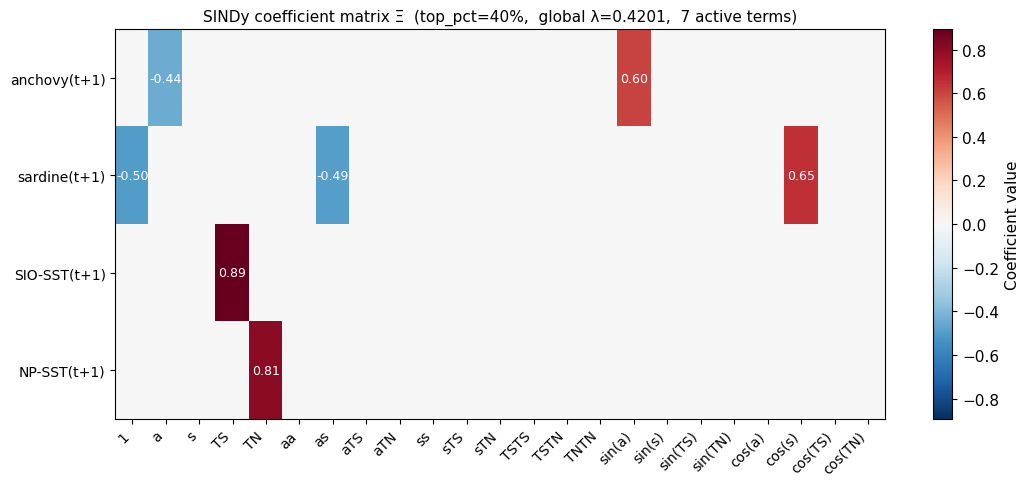

In [32]:
vmax = np.abs(Xi).max()
if vmax < 1e-10:
    print('⚠ All coefficients are zero — raise top_pct and re-run.')
else:
    fig, ax = plt.subplots(figsize=(11, 5))
    im = ax.imshow(Xi.T, aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax)

    ax.set_xticks(range(len(feat)))
    ax.set_xticklabels(feat, rotation=45, ha='right', fontsize=10)
    ax.set_yticks(range(4))
    ax.set_yticklabels(['anchovy(t+1)', 'sardine(t+1)', 'SIO-SST(t+1)', 'NP-SST(t+1)'], fontsize=10)

    for i in range(4):
        for j in range(len(feat)):
            v = Xi[j, i]
            if abs(v) > 1e-10:
                ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                        fontsize=9, color='white' if abs(v) > 0.4 * vmax else 'black')

    plt.colorbar(im, ax=ax, label='Coefficient value')
    ax.set_title(
        f'SINDy coefficient matrix Ξ  '
        f'(top_pct={TOP_PCT}%,  global λ={lamb:.4f},  '
        f'{np.sum(np.abs(Xi)>1e-10)} active terms)', fontsize=11)
    plt.tight_layout(); plt.show()

---
## Step 10 — Scatter plots: key pairwise lagged relationships

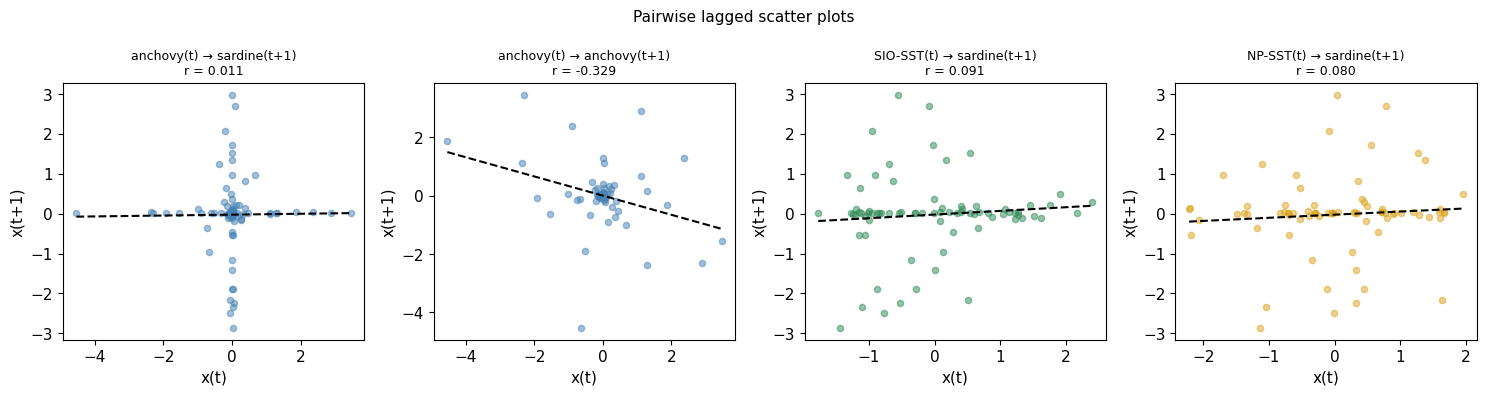

In [33]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
pairs = [
    (anchovy[:-1], sardine[1:],  'anchovy(t) → sardine(t+1)',  axes[0], 'steelblue'),
    (anchovy[:-1], anchovy[1:],  'anchovy(t) → anchovy(t+1)',  axes[1], 'steelblue'),
    (sio_sst[:-1], sardine[1:],  'SIO-SST(t) → sardine(t+1)', axes[2], 'seagreen'),
    (np_sst[:-1],  sardine[1:],  'NP-SST(t) → sardine(t+1)',  axes[3], 'goldenrod'),
]
for x_vals, y_vals, title, ax, col in pairs:
    ax.scatter(x_vals, y_vals, color=col, alpha=0.5, s=20)
    m, b = np.polyfit(x_vals, y_vals, 1)
    xline = np.linspace(x_vals.min(), x_vals.max(), 50)
    ax.plot(xline, m*xline+b, 'k--', lw=1.5)
    r = np.corrcoef(x_vals, y_vals)[0, 1]
    ax.set_title(f'{title}\nr = {r:.3f}', fontsize=9)
    ax.set_xlabel('x(t)'); ax.set_ylabel('x(t+1)')
plt.suptitle('Pairwise lagged scatter plots', fontsize=11)
plt.tight_layout(); plt.show()